In [1]:
import ot

ModuleNotFoundError: No module named 'ot'

In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import torch
from operators.fourier import fftc, ifftc
from visualization.image import plot_image

CONTRASTS = ("flair", "t1", "t1ce", "t2")

def load_case(case, root="../datasets/BraTS/BraTS2021_DataSet",
              contrasts=CONTRASTS, with_seg=False):
    """
    
    Quick-load one BraTS case as raw volumes — no preprocessing.

    case     : case dir name (e.g. "BraTS2021_00000") or a full path to it
    returns  : dict {contrast: np.ndarray of shape (H, W, D)}, + "seg" if requested
    """
    case_dir = case if os.path.isdir(case) else os.path.join(root, case)

    def _load(tag):
        matches = glob.glob(os.path.join(case_dir, f"*_{tag}.nii.gz"))
        if not matches:
            raise FileNotFoundError(f"No '*_{tag}.nii.gz' in {case_dir}")
        return np.asarray(nib.load(matches[0]).get_fdata(), dtype=np.float32)

    out = {c: _load(c) for c in contrasts}
    if with_seg:
        out["seg"] = _load("seg")
    return out

In [3]:
from __future__ import annotations

@torch.no_grad()
def _kmeanspp_init(x, K, gen):
    """k-means++ seeding on (M, D) -> (K, D)."""
    M = x.shape[0]
    centroids = torch.empty(K, x.shape[1], device=x.device, dtype=x.dtype)
    centroids[0] = x[torch.randint(0, M, (1,), generator=gen, device=x.device)]
    closest = torch.cdist(x, centroids[:1]).squeeze(1).pow(2)
    for i in range(1, K):
        probs = closest / closest.sum().clamp(min=1e-12)
        centroids[i] = x[torch.multinomial(probs, 1, generator=gen)]
        closest = torch.minimum(closest, torch.cdist(x, centroids[i:i+1]).squeeze(1).pow(2))
    return centroids


@torch.no_grad()
def minibatch_kmeans(
    x: torch.Tensor,
    n_clusters: int,
    batch_size: int = 1024,
    max_iter: int = 100,
    tol: float = 0.0,
    max_no_improvement: int | None = 10,
    n_init: int = 3,
    init_size: int | None = None,
    reassignment_ratio: float = 0.01,
    seed: int | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    GPU-compatible Mini-Batch K-Means, following sklearn.cluster.MiniBatchKMeans.

    Args mirror the sklearn names. Returns (labels (N,), centroids (K, D)).
    """
    N, D = x.shape
    K = n_clusters
    device, dtype = x.device, x.dtype
    bs = min(batch_size, N)

    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    if init_size is None:
        init_size = 3 * bs if 3 * bs >= K else 3 * K
    init_size = min(init_size, N)

    # --- multiple inits on a random subset, keep best by inertia on a validation subset ---
    valid_idx = torch.randint(0, N, (init_size,), generator=gen, device=device)
    x_valid = x[valid_idx]
    best_centroids, best_inertia = None, None
    for _ in range(n_init):
        sub = x[torch.randint(0, N, (init_size,), generator=gen, device=device)]
        c = _kmeanspp_init(sub, K, gen)
        inertia = torch.cdist(x_valid, c).amin(dim=1).pow(2).sum()
        if best_inertia is None or inertia < best_inertia:
            best_centroids, best_inertia = c, inertia
    centroids = best_centroids

    # --- streaming optimization ---
    counts = torch.zeros(K, device=device, dtype=dtype)      # running weight per center
    n_steps = (max_iter * N) // bs
    ewa = ewa_min = None
    no_improve = 0
    since_reassign = 0
    alpha = min(bs * 2.0 / (N + 1), 1.0)                     # EWA smoothing factor

    for step in range(n_steps):
        idx = torch.randint(0, N, (bs,), generator=gen, device=device)
        batch = x[idx]

        dists = torch.cdist(batch, centroids)                # (bs, K)
        labels = dists.argmin(dim=1)
        batch_inertia = dists.gather(1, labels[:, None]).squeeze(1).pow(2).sum() / bs

        # per-center batch sums and counts
        bcounts = torch.zeros(K, device=device, dtype=dtype)
        bcounts.index_add_(0, labels, torch.ones(bs, device=device, dtype=dtype))
        bsums = torch.zeros(K, D, device=device, dtype=dtype)
        bsums.index_add_(0, labels, batch)

        # incremental-mean update with decaying learning rate eta = 1 / new_count
        old = centroids.clone()
        active = bcounts > 0
        new_counts = counts + bcounts
        eta = torch.where(active, 1.0 / new_counts.clamp(min=1), torch.zeros_like(counts))
        centroids = centroids + eta.unsqueeze(1) * (bsums - bcounts.unsqueeze(1) * centroids)
        counts = new_counts

        # --- periodic reassignment of low-count centers ---
        since_reassign += bs
        if (counts == 0).any() or since_reassign >= 10 * K:
            since_reassign = 0
            to_reassign = counts < reassignment_ratio * counts.max().clamp(min=1)
            n_re = int(to_reassign.sum())
            if 0 < n_re <= bs // 2:
                # pick batch points far from their nearest center (distance-weighted)
                d = torch.cdist(batch, centroids).amin(dim=1).pow(2)
                pick = torch.multinomial(d / d.sum().clamp(min=1e-12), n_re, generator=gen)
                centroids[to_reassign] = batch[pick]
                counts[to_reassign] = 0

        # --- convergence checks (skip first step: it's just init inertia) ---
        if step == 0:
            continue
        if tol > 0.0 and (centroids - old).pow(2).sum() <= tol:
            break
        ewa = batch_inertia if ewa is None else ewa * (1 - alpha) + batch_inertia * alpha
        if ewa_min is None or ewa < ewa_min:
            ewa_min, no_improve = ewa, 0
        else:
            no_improve += 1
        if max_no_improvement is not None and no_improve >= max_no_improvement:
            break

    # final hard assignment over all points (sklearn computes labels_ at the end)
    labels = torch.cdist(x, centroids).argmin(dim=1)
    return labels, centroids

In [4]:
os.chdir('/scratch/ee2178/ImMAP')

In [5]:
data = load_case("BraTS2021_00000")

In [6]:
# Load flair image
flair = data['flair']
t1ce = data['t1ce']
t1 = data['t1']
t2 = data['t2']

x = torch.tensor(np.array([flair, t1, t1ce, t2]))

In [51]:
slice_idx = 70
img1 = flair[:, :, slice_idx] 
img1 = img1 / np.percentile(img1, 99.5)
img2 = t1[:, :, slice_idx]
img2 = img2 / np.percentile(img2, 99.5)
img3 = t2[:, :, slice_idx]
img3 = img3 / np.percentile(img3, 99.5)
ref = t1ce[:, :, slice_idx-1]
ref = ref / np.percentile(ref, 99.5)
gt = t1ce[:, :, slice_idx]

In [12]:
# CONTRAST SYNTHESIS TESTING WITH OT
import numpy as np


def ot_histogram_match_1d(img, ref, bins=256):

    xmin = min(img.min(), ref.min())
    xmax = max(img.max(), ref.max())

    h_src, edges = np.histogram(
        img.ravel(),
        bins=bins,
        range=(xmin, xmax)
    )

    h_ref, _ = np.histogram(
        ref.ravel(),
        bins=bins,
        range=(xmin, xmax)
    )

    cdf_src = np.cumsum(h_src)
    cdf_ref = np.cumsum(h_ref)

    cdf_src = cdf_src / cdf_src[-1]
    cdf_ref = cdf_ref / cdf_ref[-1]

    centers = 0.5 * (edges[:-1] + edges[1:])

    T = np.interp(
        cdf_src,
        cdf_ref,
        centers
    )

    idx = np.digitize(img.ravel(), edges[:-1]) - 1
    idx = np.clip(idx, 0, bins - 1)

    return T[idx].reshape(img.shape)

In [44]:
combined = (img1 + img2 + img3) / 3

# Compute a foreground mask
mask = combined > 0
output = ot_histogram_match_1d(
    combined[mask],
    ref[mask],
    bins=512
)

out = np.zeros(img1.shape)
out[mask] = output

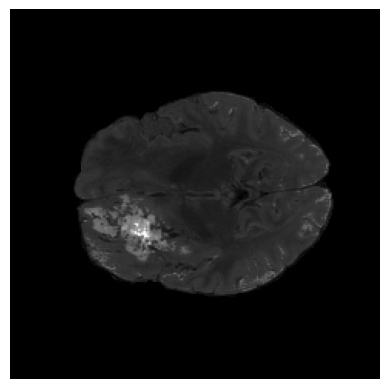

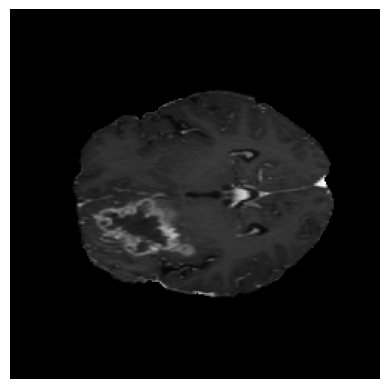

In [52]:
# plot_image(torch.from_numpy(flair[:, :, slice_idx]))
# plot_image(torch.from_numpy(t1[:, :, slice_idx]))
# plot_image(torch.from_numpy(t2[:, :, slice_idx]))
plot_image(torch.from_numpy(out))
plot_image(torch.from_numpy(gt))

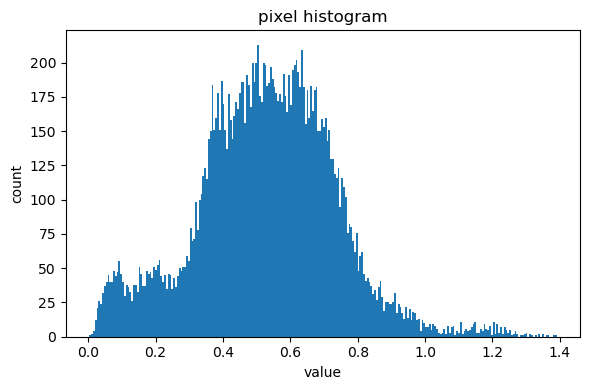

min=0.002975  max=1.391  mean=0.5285  std=0.208  p1=0.02429  p99=1.288


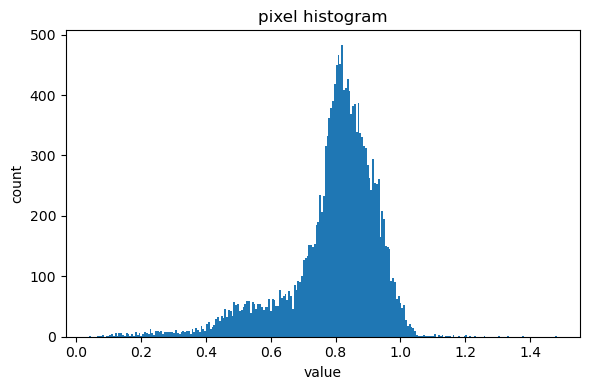

min=0.03985  max=1.482  mean=0.7913  std=0.1442  p1=0.1155  p99=1.135


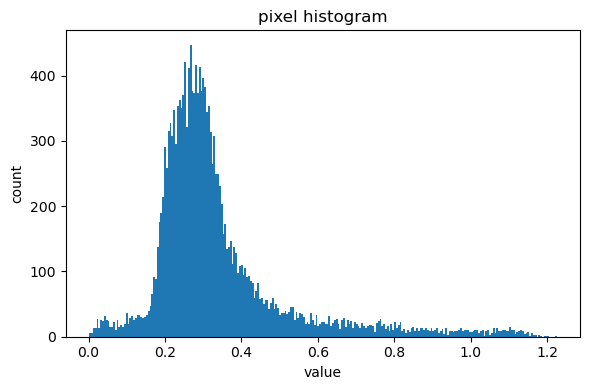

min=0.001658  max=1.225  mean=0.3395  std=0.1828  p1=0.01359  p99=1.155


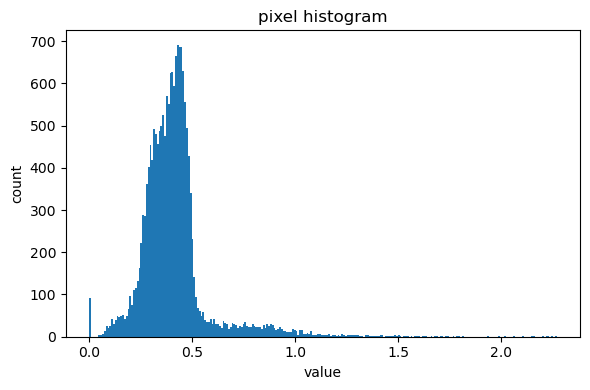

min=0  max=2.27  mean=0.4136  std=0.1786  p1=0  p99=1.865


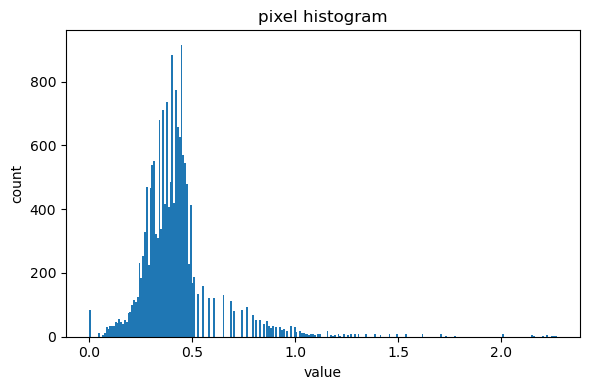

min=0.002216  max=2.267  mean=0.4151  std=0.1815  p1=0.002216  p99=2.01


In [55]:
plot_hist(torch.from_numpy(img1[mask]), bins=256, title="pixel histogram")
plot_hist(torch.from_numpy(img2[mask]), bins=256, title="pixel histogram")
plot_hist(torch.from_numpy(img3[mask]), bins=256, title="pixel histogram")
plot_hist(torch.from_numpy(ref[mask]), bins=256, title="pixel histogram")
plot_hist(torch.from_numpy(out[mask]), bins=256, title="pixel histogram")

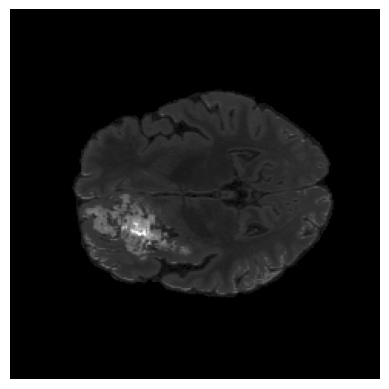

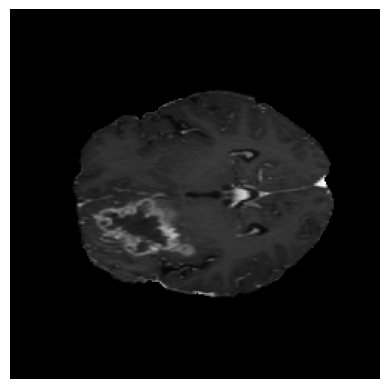

In [23]:
plot_image(torch.from_numpy(output))
plot_image(torch.from_numpy(gt))

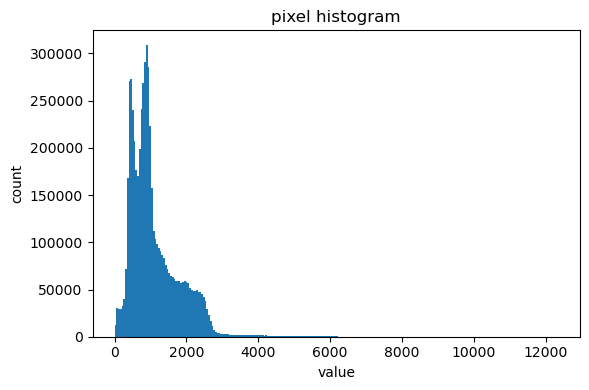

min=1  max=1.234e+04  mean=1110  std=760.3  p1=36  p99=7284


In [24]:
import matplotlib.pyplot as plt

def plot_hist(img, bins=256, title="pixel histogram"):
    x = img.detach().cpu()
    x = x.abs() if torch.is_complex(x) else x      # magnitude for complex
    x = x.flatten().float()
    plt.figure(figsize=(6, 4))
    plt.hist(x.numpy(), bins=bins)
    plt.xlabel("value"); plt.ylabel("count"); plt.title(title)
    plt.tight_layout(); plt.show()
    # handy stats for picking a normalization
    print(f"min={x.min():.4g}  max={x.max():.4g}  "
          f"mean={x.mean():.4g}  std={x.std():.4g}  "
         f"p1={x.quantile(0.001):.4g}  p99={x.quantile(0.999):.4g}")

def zscore_channelwise(img, eps=1e-8, channel_dim=-3):
    """
    Per-channel z-score normalization.
    Expects (..., C, H, W); set channel_dim if your layout differs.
    Works for real and complex tensors.
    Returns (normalized, mean, std) so you can invert it later.
    """
    # reduce over every axis except the channel axis
    dims = [d for d in range(img.ndim) if d != channel_dim % img.ndim]

    mean = img.mean(dim=dims, keepdim=True)
    # variance via |x - mean|^2 works for both real and complex
    var = (img - mean).abs().pow(2).mean(dim=dims, keepdim=True)
    std = var.sqrt().clamp_min(eps)          # real, positive

    return (img - mean) / std, mean, std
# Swap contrast to channel dimension, slices to batch dim, and swap spatial dims for viewing. 
y = x.permute(3, 0, 2, 1)

plot_hist(y[y>0])

y = y.clamp(min = 0., max = 5063.)

# Channelwise z score normalization
y, _, _ = zscore_channelwise(y, eps=1e-8, channel_dim=-3)

In [7]:
# Testing PCA --> TVD --> K-means pipeline
from preprocessing.pca import pca_pixelwise as pca
from preprocessing.kmeans import kmeans
from solvers.tvd import tvd_fista
from operators import Identity

# First PCA
y = y.to('cuda')
x_pcproj, _, _ = pca(y, n_components = 4)

# Next, TVD (converted from wts = 40 from Lavanya's code)
x_projden, pstar, _ = tvd_fista(x_pcproj.unsqueeze(1), lam = 1/80, eta = 8.0, maxit = 500, tol = 1e-3, verbose = True, isotropic=True)
x_projden = x_projden.squeeze(1).real

# now, do kmeans
# Reshape to desired input shape
x_in = x_projden.permute(0, 2, 3, 1).reshape(-1, 4)
# x_clustered, x_centroids = kmeans(x_in, n_clusters = 20)
x_clustered, x_centroids = minibatch_kmeans(x_in, n_clusters = 20)

Iteration 0: Maximum Residual is 0.013
Iteration 1: Maximum Residual is 0.005
Iteration 2: Maximum Residual is 0.003
Iteration 3: Maximum Residual is 0.002
Iteration 4: Maximum Residual is 0.001
Iteration 5: Maximum Residual is 0.001
Iteration 6: Maximum Residual is 0.001
Iteration 7: Maximum Residual is 0.001
Iteration 8: Maximum Residual is 0.001
Completed FISTA at Iteration 8


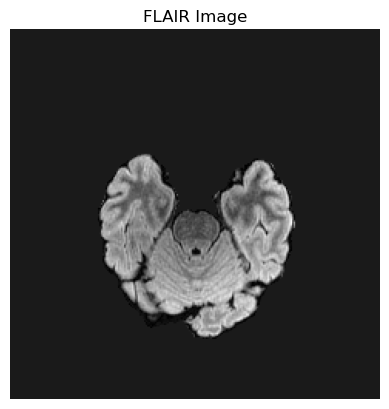

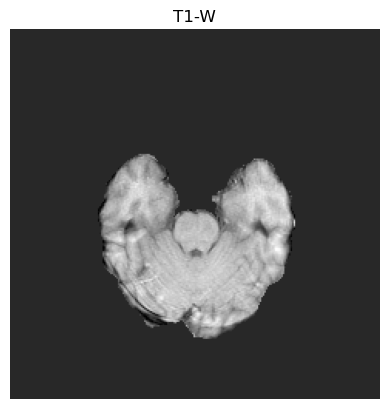

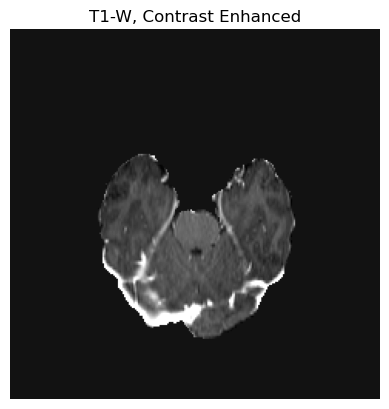

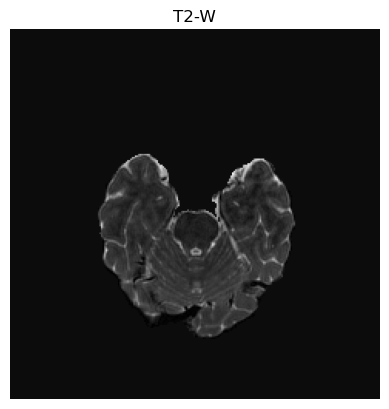

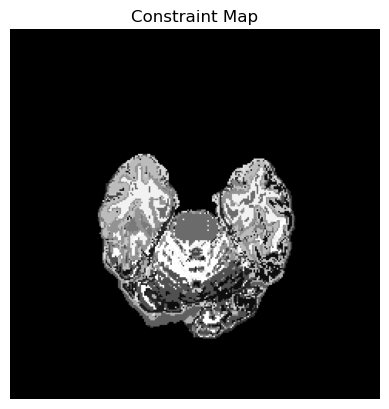

In [11]:
# plot a constraint map
from preprocessing.kmeans import kmeans
slice_idx = 45
x_in = x_projden[slice_idx:slice_idx+1].permute(0, 2, 3, 1).reshape(-1, 4)
x_clustered, x_centroids = kmeans(x_in, n_clusters = 20)
# Reshape
B, C, H, W = y.shape
x_clustered = x_clustered.reshape( H, W)

plot_image(y[slice_idx, 0], title = 'FLAIR Image')
plot_image(y[slice_idx, 1], title = 'T1-W')
plot_image(y[slice_idx, 2], title = 'T1-W, Contrast Enhanced')
plot_image(y[slice_idx, 3], title = 'T2-W')
plot_image(x_clustered, title = 'Constraint Map')